In [1]:
import sys
from pathlib import Path

# Move from notebooks/ -> ml/
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project Root:", PROJECT_ROOT)

Project Root: /home/rupali-jha/solar-flare-watch/ml


In [2]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from src.nowcasting import *

In [3]:
DATA_DIR = Path("../data/processed")

flare_df = pd.read_parquet(
    DATA_DIR / "solexs_lightcurve.parquet"
)

flare_df = flare_df[
    [
        "DATETIME",
        "COUNTS",
    ]
].copy()

flare_df.head()

,DATETIME,COUNTS
0,2026-06-24 00:00:00,56.0
1,2026-06-24 00:00:01,56.0
2,2026-06-24 00:00:02,64.0
3,2026-06-24 00:00:03,71.0
4,2026-06-24 00:00:04,55.0


In [4]:
print(flare_df.shape)

print(flare_df.isna().sum())

print(flare_df.dtypes)

(86400, 2)
DATETIME    0
COUNTS      0
dtype: int64
DATETIME    datetime64[ms]
COUNTS             float64
dtype: object


In [5]:
flare_df["BACKGROUND"] = estimate_background(
    flare_df["COUNTS"]
)

sigma = estimate_noise(
    flare_df["COUNTS"],
    flare_df["BACKGROUND"]
)

flare_df["THRESHOLD"] = adaptive_threshold(
    flare_df["BACKGROUND"],
    sigma,
)

print("Estimated Noise :", sigma)

Estimated Noise : 4.4478


In [6]:
peaks, properties = detect_candidate_peaks(
    flare_df
)

print("Candidate Peaks :", len(peaks))

Candidate Peaks : 81


In [7]:
peaks, properties = detect_candidate_peaks(flare_df)

print(len(peaks))

81


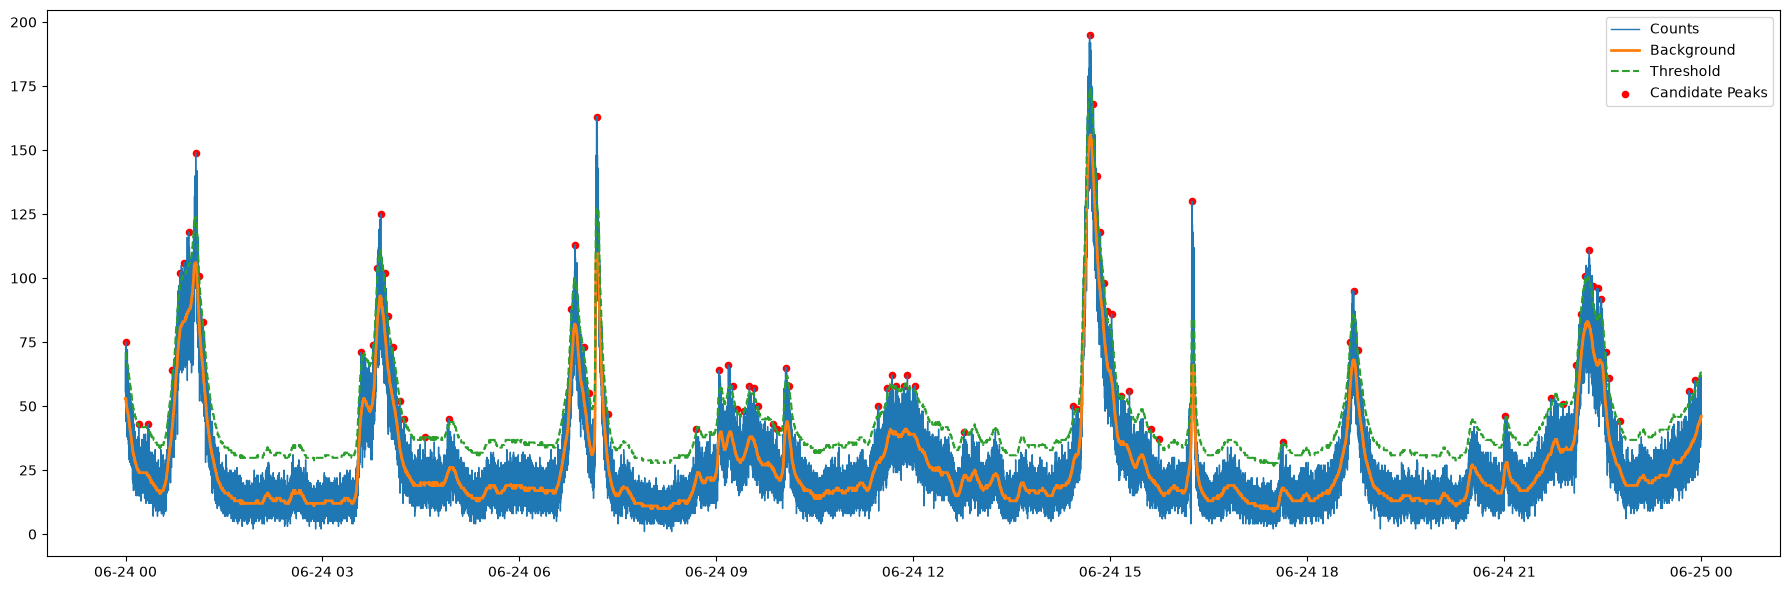

In [8]:
plt.figure(figsize=(18,6))

plt.plot(
    flare_df["DATETIME"],
    flare_df["COUNTS"],
    lw=1,
    label="Counts",
)

plt.plot(
    flare_df["DATETIME"],
    flare_df["BACKGROUND"],
    lw=2,
    label="Background",
)

plt.plot(
    flare_df["DATETIME"],
    flare_df["THRESHOLD"],
    "--",
    label="Threshold",
)

plt.scatter(
    flare_df.iloc[peaks]["DATETIME"],
    flare_df.iloc[peaks]["COUNTS"],
    color="red",
    s=20,
    label="Candidate Peaks",
)

plt.legend()

plt.tight_layout()

plt.show()

In [9]:
events = merge_nearby_peaks(
    flare_df,
    peaks,
)

print(events.head())

print("Merged flare events :", len(events))

   start_idx  peak_idx  end_idx
0         11        11       11
1        724       724      724
2       1245      1245     1245
3       2575      2575     2575
4       3001      3466     3466
Merged flare events : 42


In [10]:
events = detect_flare_events(
    flare_df,
)

print(events.head())

print("Detected flare events:", len(events))

   start_idx  peak_idx  end_idx
0          3         3        4
1         11        11       12
2         26        26       27
3        101       102      103
4        149       149      150
Detected flare events: 428


In [11]:
catalog = pd.DataFrame({

    "start_time":
        flare_df.loc[
            events["start_idx"],
            "DATETIME"
        ].values,

    "peak_time":
        flare_df.loc[
            events["peak_idx"],
            "DATETIME"
        ].values,

    "end_time":
        flare_df.loc[
            events["end_idx"],
            "DATETIME"
        ].values,

    "peak_counts":
        flare_df.loc[
            events["peak_idx"],
            "COUNTS"
        ].values,

})

In [12]:
catalog["duration_sec"] = (
    catalog["end_time"] -
    catalog["start_time"]
).dt.total_seconds()

In [13]:
catalog["confidence"] = (
    catalog["peak_counts"] /
    catalog["peak_counts"].max()
).round(3)

In [14]:
catalog.head(10)

,start_time,peak_time,end_time,peak_counts,duration_sec,confidence
0,2026-06-24 00:00:03,2026-06-24 00:00:03,2026-06-24 00:00:04,71.0,1.0,0.364
1,2026-06-24 00:00:11,2026-06-24 00:00:11,2026-06-24 00:00:12,75.0,1.0,0.385
2,2026-06-24 00:00:26,2026-06-24 00:00:26,2026-06-24 00:00:27,73.0,1.0,0.374
3,2026-06-24 00:01:41,2026-06-24 00:01:42,2026-06-24 00:01:43,72.0,2.0,0.369
4,2026-06-24 00:02:29,2026-06-24 00:02:29,2026-06-24 00:02:30,66.0,1.0,0.338
5,2026-06-24 00:12:04,2026-06-24 00:12:04,2026-06-24 00:12:05,43.0,1.0,0.221
6,2026-06-24 00:20:45,2026-06-24 00:20:45,2026-06-24 00:20:46,43.0,1.0,0.221
7,2026-06-24 00:21:18,2026-06-24 00:21:18,2026-06-24 00:21:19,41.0,1.0,0.210
8,2026-06-24 00:42:11,2026-06-24 00:42:11,2026-06-24 00:42:12,60.0,1.0,0.308
9,2026-06-24 00:42:55,2026-06-24 00:42:55,2026-06-24 00:42:56,64.0,1.0,0.328


In [15]:
print(len(catalog))

428


In [16]:
flare_df = flare_df.copy()

flare_df["SMOOTH"] = (
    flare_df["COUNTS"]
    .rolling(
        window=31,
        center=True,
        min_periods=1
    )
    .median()
)

In [17]:
from scipy.signal import find_peaks

peaks, properties = find_peaks(
    flare_df["SMOOTH"],
    prominence=30,      # tune if needed
    distance=600,       # at least 10 minutes apart
)

print("Major Peaks:", len(peaks))

Major Peaks: 11


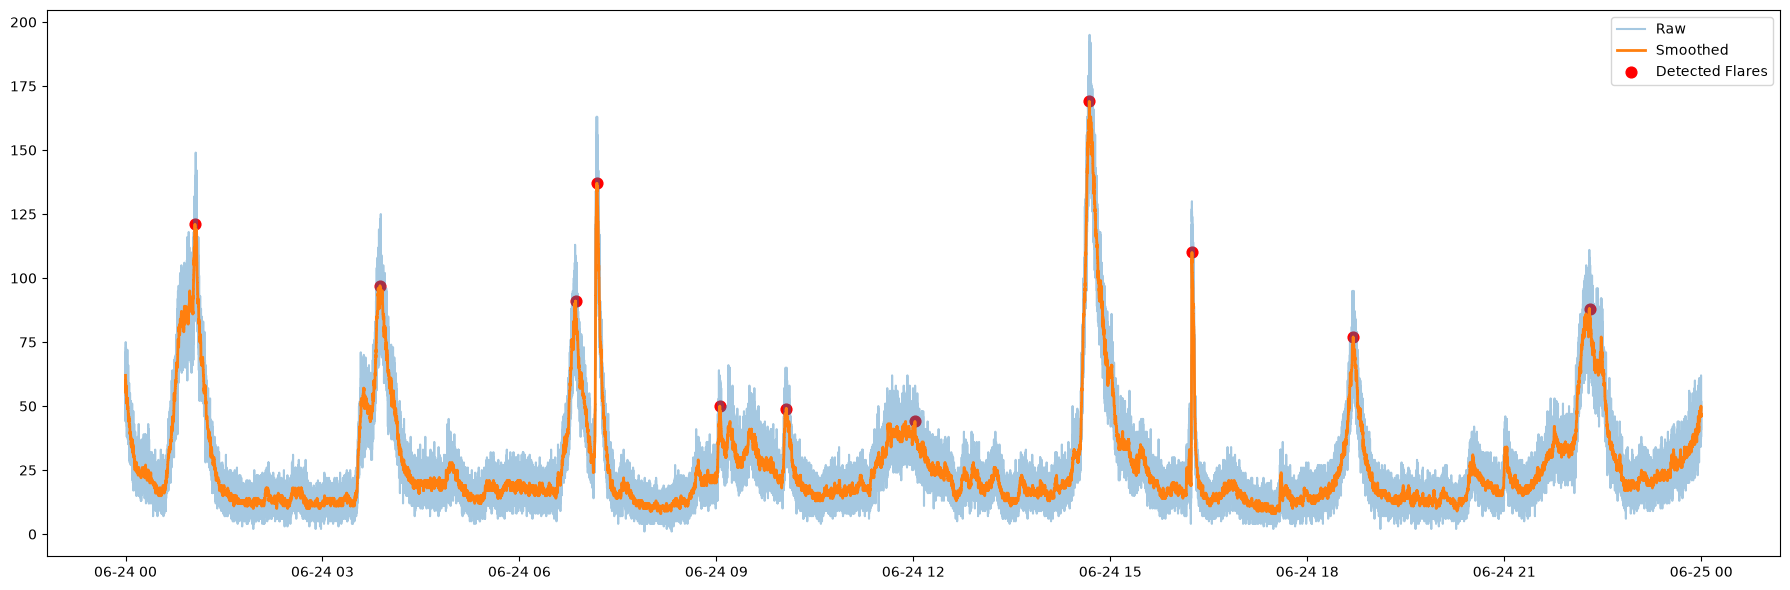

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18,6))

plt.plot(
    flare_df["DATETIME"],
    flare_df["COUNTS"],
    alpha=0.4,
    label="Raw"
)

plt.plot(
    flare_df["DATETIME"],
    flare_df["SMOOTH"],
    linewidth=2,
    label="Smoothed"
)

plt.scatter(
    flare_df.iloc[peaks]["DATETIME"],
    flare_df.iloc[peaks]["SMOOTH"],
    color="red",
    s=60,
    label="Detected Flares"
)

plt.legend()
plt.tight_layout()
plt.show()

In [19]:
catalog = pd.DataFrame({
    "peak_time": flare_df.iloc[peaks]["DATETIME"].values,
    "peak_counts": flare_df.iloc[peaks]["COUNTS"].values,
})

catalog["confidence"] = (
    catalog["peak_counts"] /
    catalog["peak_counts"].max()
).round(3)

catalog

,peak_time,peak_counts,confidence
0,2026-06-24 01:03:27,124.0,0.705
1,2026-06-24 03:52:34,109.0,0.619
2,2026-06-24 06:51:21,81.0,0.460
3,2026-06-24 07:10:31,163.0,0.926
4,2026-06-24 09:03:03,58.0,0.330
5,2026-06-24 10:03:47,49.0,0.278
6,2026-06-24 12:01:24,54.0,0.307
7,2026-06-24 14:40:48,176.0,1.000
8,2026-06-24 16:14:37,102.0,0.580
9,2026-06-24 18:41:55,59.0,0.335


In [20]:
print(len(peaks))

11


In [21]:
catalog = pd.DataFrame({
    "peak_time": flare_df.iloc[peaks]["DATETIME"].values,
    "peak_counts": flare_df.iloc[peaks]["COUNTS"].values,
})


In [22]:
rows = []

for peak in peaks:

    start, end = find_flare_boundaries(
        flare_df,
        peak,
    )

    rows.append({

        "start_time": flare_df.iloc[start]["DATETIME"],

        "peak_time": flare_df.iloc[peak]["DATETIME"],

        "end_time": flare_df.iloc[end]["DATETIME"],

        "peak_counts": flare_df.iloc[peak]["COUNTS"],

        "duration_sec": (
            flare_df.iloc[end]["DATETIME"] -
            flare_df.iloc[start]["DATETIME"]
        ).total_seconds(),

        "integrated_counts": (
            flare_df.iloc[start:end]["COUNTS"].sum()
        ),

    })

catalog = pd.DataFrame(rows)

catalog

,start_time,peak_time,end_time,peak_counts,duration_sec,integrated_counts
0,2026-06-24 01:02:57,2026-06-24 01:03:27,2026-06-24 01:05:10,124.0,133.0,15460.0
1,2026-06-24 03:52:31,2026-06-24 03:52:34,2026-06-24 03:53:07,109.0,36.0,3493.0
2,2026-06-24 06:50:12,2026-06-24 06:51:21,2026-06-24 06:51:44,81.0,92.0,8194.0
3,2026-06-24 07:09:50,2026-06-24 07:10:31,2026-06-24 07:12:00,163.0,130.0,16826.0
4,2026-06-24 09:02:05,2026-06-24 09:03:03,2026-06-24 09:04:12,58.0,127.0,5755.0
5,2026-06-24 10:02:27,2026-06-24 10:03:47,2026-06-24 10:05:03,49.0,156.0,7194.0
6,2026-06-24 12:00:46,2026-06-24 12:01:24,2026-06-24 12:01:48,54.0,62.0,2602.0
7,2026-06-24 14:40:21,2026-06-24 14:40:48,2026-06-24 14:41:14,176.0,53.0,8590.0
8,2026-06-24 16:14:16,2026-06-24 16:14:37,2026-06-24 16:16:29,102.0,133.0,12700.0
9,2026-06-24 18:41:03,2026-06-24 18:41:55,2026-06-24 18:42:40,59.0,97.0,7111.0


In [25]:
catalog["confidence"] = (
    0.6 * (catalog["peak_counts"] / catalog["peak_counts"].max())
    +
    0.4 * (catalog["integrated_counts"] / catalog["integrated_counts"].max())
).round(3)


def classify(count):

    if count >= 170:
        return "Extreme"

    elif count >= 120:
        return "High"

    elif count >= 80:
        return "Moderate"

    else:
        return "Low"


catalog["severity"] = catalog["peak_counts"].apply(classify)

catalog

,start_time,peak_time,end_time,peak_counts,duration_sec,integrated_counts,confidence,severity
0,2026-06-24 01:02:57,2026-06-24 01:03:27,2026-06-24 01:05:10,124.0,133.0,15460.0,0.790,High
1,2026-06-24 03:52:31,2026-06-24 03:52:34,2026-06-24 03:53:07,109.0,36.0,3493.0,0.455,Moderate
2,2026-06-24 06:50:12,2026-06-24 06:51:21,2026-06-24 06:51:44,81.0,92.0,8194.0,0.471,Moderate
3,2026-06-24 07:09:50,2026-06-24 07:10:31,2026-06-24 07:12:00,163.0,130.0,16826.0,0.956,High
4,2026-06-24 09:02:05,2026-06-24 09:03:03,2026-06-24 09:04:12,58.0,127.0,5755.0,0.335,Low
5,2026-06-24 10:02:27,2026-06-24 10:03:47,2026-06-24 10:05:03,49.0,156.0,7194.0,0.338,Low
6,2026-06-24 12:00:46,2026-06-24 12:01:24,2026-06-24 12:01:48,54.0,62.0,2602.0,0.246,Low
7,2026-06-24 14:40:21,2026-06-24 14:40:48,2026-06-24 14:41:14,176.0,53.0,8590.0,0.804,Extreme
8,2026-06-24 16:14:16,2026-06-24 16:14:37,2026-06-24 16:16:29,102.0,133.0,12700.0,0.650,Moderate
9,2026-06-24 18:41:03,2026-06-24 18:41:55,2026-06-24 18:42:40,59.0,97.0,7111.0,0.370,Low


In [26]:
catalog

,start_time,peak_time,end_time,peak_counts,duration_sec,integrated_counts,confidence,severity
0,2026-06-24 01:02:57,2026-06-24 01:03:27,2026-06-24 01:05:10,124.0,133.0,15460.0,0.790,High
1,2026-06-24 03:52:31,2026-06-24 03:52:34,2026-06-24 03:53:07,109.0,36.0,3493.0,0.455,Moderate
2,2026-06-24 06:50:12,2026-06-24 06:51:21,2026-06-24 06:51:44,81.0,92.0,8194.0,0.471,Moderate
3,2026-06-24 07:09:50,2026-06-24 07:10:31,2026-06-24 07:12:00,163.0,130.0,16826.0,0.956,High
4,2026-06-24 09:02:05,2026-06-24 09:03:03,2026-06-24 09:04:12,58.0,127.0,5755.0,0.335,Low
5,2026-06-24 10:02:27,2026-06-24 10:03:47,2026-06-24 10:05:03,49.0,156.0,7194.0,0.338,Low
6,2026-06-24 12:00:46,2026-06-24 12:01:24,2026-06-24 12:01:48,54.0,62.0,2602.0,0.246,Low
7,2026-06-24 14:40:21,2026-06-24 14:40:48,2026-06-24 14:41:14,176.0,53.0,8590.0,0.804,Extreme
8,2026-06-24 16:14:16,2026-06-24 16:14:37,2026-06-24 16:16:29,102.0,133.0,12700.0,0.650,Moderate
9,2026-06-24 18:41:03,2026-06-24 18:41:55,2026-06-24 18:42:40,59.0,97.0,7111.0,0.370,Low


In [27]:
catalog.to_csv(
    "../data/processed/solexs_flare_catalog.csv",
    index=False,
)

catalog.to_parquet(
    "../data/processed/solexs_flare_catalog.parquet",
    index=False,
)